## **IMAGE QUALITY ANALYSIS**

SSIM should be as high as possible. Ideally SSIM should be 1 i.e., 100%

PSNR ideally should be between 30 and 50

FID Score should be as close to 0 as possible

Difference in sharpness between mean of real_images and mean Synthetic images should be as close to 0 as possible.

In [2]:
import os
import cv2
import random
import shutil
import warnings
import numpy as np
import seaborn as sns
from tqdm import tqdm
from numpy import cov
from PIL import Image
from numpy import trace
import tensorflow as tf
from numpy import asarray
from tensorflow import keras
from scipy.linalg import sqrtm
from numpy import iscomplexobj
import matplotlib.pyplot as plt
from numpy.random import randint
warnings.filterwarnings("ignore")
from tensorflow.keras import layers
from skimage.transform import resize
from IPython.display import FileLink
from keras.datasets.mnist import load_data
from keras.applications.inception_v3 import InceptionV3
from skimage.metrics import structural_similarity as ssim
from keras.applications.inception_v3 import preprocess_input
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

In [3]:
tf.random.set_seed(5638)
random.seed(5638)
noise_dim = 256
IMG_SHAPE = (128, 128, 1)
BATCH_SIZE = 64

In [4]:
def calculate_fid(generated_images, real_images):
    # scale an array of images to a new size
    def scale_images(images, new_shape):
        images_list = []
        for image in images:
            # resize with nearest neighbor interpolation
            resized_image = cv2.cvtColor(cv2.resize(image, new_shape, cv2.INTER_NEAREST), cv2.COLOR_GRAY2BGR)
            # store the resized images
            images_list.append(resized_image)
        return asarray(images_list)
    # prepare the inception v3 model
    model = InceptionV3(include_top=False, pooling='avg', input_shape=(299,299,3))
    # resize images
    generated_images = scale_images(generated_images, (299,299))
    real_images = scale_images(real_images, (299,299))
    # pre-process images
    generated_images = preprocess_input(generated_images)
    real_images = preprocess_input(real_images)
    # calculate feature embeddings
    embeddings1 = model.predict(generated_images)
    embeddings2 = model.predict(real_images)
    # calculate mean and covariance statistics
    mu1, sigma1 = embeddings1.mean(axis=0), cov(embeddings1, rowvar=False)
    mu2, sigma2 = embeddings2.mean(axis=0), cov(embeddings2, rowvar=False)
    # calculate sum squared difference between means
    ssdiff = np.sum((mu1 - mu2)**2.0)
    # calculate sqrt of product between cov
    covmean = sqrtm(sigma1.dot(sigma2))
    # check and correct imaginary numbers from sqrt
    if iscomplexobj(covmean):
        covmean = covmean.real
    # calculate fid score
    fid = ssdiff + trace(sigma1 + sigma2 - 2.0 * covmean)
    return np.round(fid,2)

### **VERY MILD IMPAIRMENT**

In [6]:
best_gen_img_path = './synthetic_very_mild_impairment/'
real_img_path = './Very Mild Impairment/'

def img_to_array(folder_path = None):
    images = [cv2.imread(folder_path + image_name, cv2.COLOR_BGR2GRAY) for image_name in os.listdir(folder_path)]
    resized_images = np.array([cv2.resize(i, (IMG_SHAPE[0],IMG_SHAPE[1])) for i in images]).astype(np.float32)
    reshaped_images = resized_images.reshape(resized_images.shape[0], *IMG_SHAPE)/255.0
    return reshaped_images

real_images = img_to_array(folder_path = real_img_path)
best_gen_images = img_to_array(folder_path = best_gen_img_path)

In [16]:
calculate_fid(real_images, best_gen_images)

24/24 [==============================] - 105s 4s/step


0.07

In [23]:
# mean of all real images for this class
real_images_mean = np.mean(real_images,axis=0)
real_images_mean.shape

(128, 128, 1)

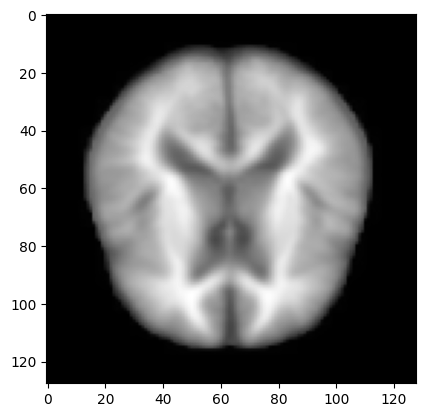

In [7]:
# this is what mean of all real images looks like
plt.imshow(real_images_mean,cmap='gray')

In [24]:
# mean of all images generated by the best generator
best_gen_images_mean = np.mean(best_gen_images,axis=0)
best_gen_images_mean.shape

(128, 128, 1)

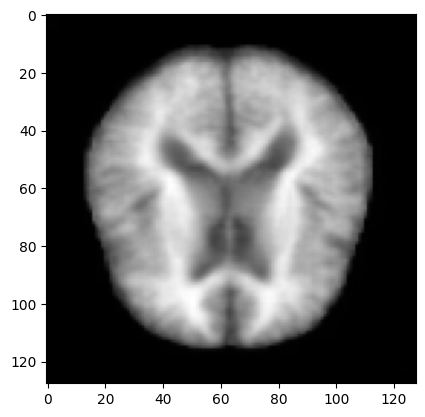

In [9]:
# this is what that mean looks like
plt.imshow(best_gen_images_mean,cmap='gray')

In [25]:
def sharpness_difference(image1, image2):
    from dom import DOM
    bgr_image1 = cv2.cvtColor(image1, cv2.COLOR_GRAY2BGR)
    shp_img1 = DOM().get_sharpness(bgr_image1)
    bgr_image2 = cv2.cvtColor(image2, cv2.COLOR_GRAY2BGR)
    shp_img2 = DOM().get_sharpness(bgr_image2)
    return np.round(abs(shp_img1 - shp_img2),2)

In [30]:
# structural similarity between mean of real images and mean of images generated by the best generator
print('SSIM = {}'.format(np.round(ssim(real_images_mean, best_gen_images_mean,channel_axis=2),2)))

SSIM = 0.97


In [27]:
# peak signal to noise ratio between mean of real images and mean of images generated by the best generator
real_images_mean = real_images_mean * 255.0
best_gen_images_mean = best_gen_images_mean * 255.0
psnr = cv2.PSNR(real_images_mean, best_gen_images_mean)
print('PSNR = {}'.format(np.round(psnr,2)))

PSNR = 33.39


In [28]:
SD = sharpness_difference(real_images_mean, best_gen_images_mean)
print('Sharpness Difference = {}'.format(SD))

Sharpness Difference = 0.05


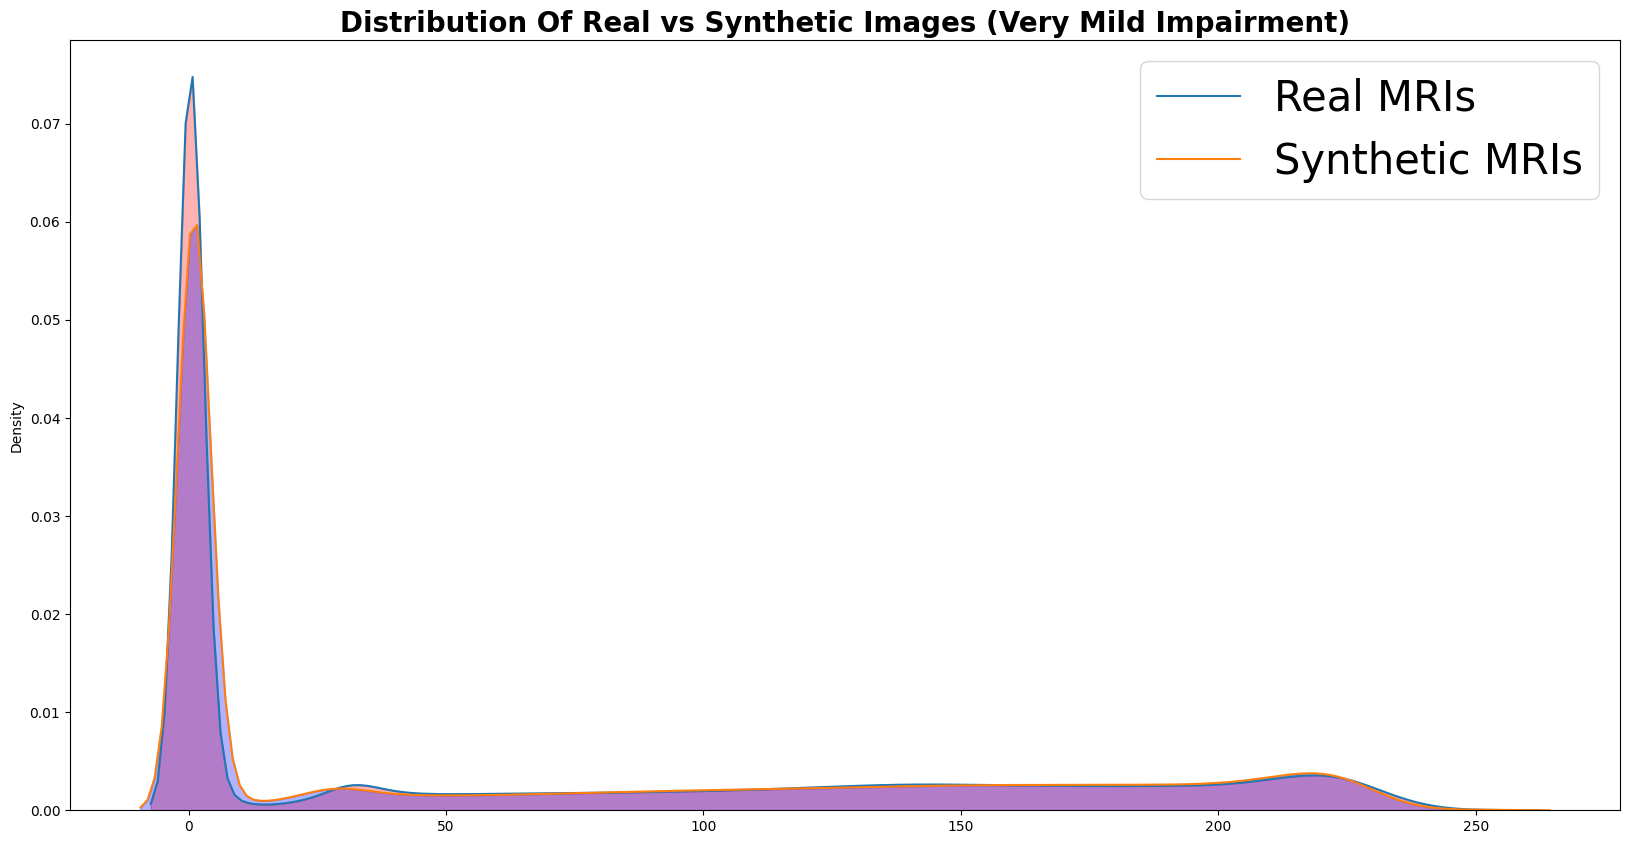

In [7]:
import warnings
warnings.filterwarnings("ignore")

# rescaling images back to 0 to 255
real_images = real_images * 255.0
best_gen_images = best_gen_images * 255.0

fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(20,10))
axs = sns.distplot(real_images, label='Real MRIs', fit_kws={"color":"red"}, hist = None)
axs = sns.distplot(best_gen_images, label='Synthetic MRIs', fit_kws={"color":"blue"}, hist = None)
# Get the two lines from the axes to generate shading
l1 = axs.lines[0]
l2 = axs.lines[1]
# Get the xy data from the lines so that we can shade
x1 = l1.get_xydata()[:,0]
y1 = l1.get_xydata()[:,1]
x2 = l2.get_xydata()[:,0]
y2 = l2.get_xydata()[:,1]
axs.fill_between(x1,y1, color="red", alpha=0.3)
axs.fill_between(x2,y2, color="blue", alpha=0.3)
plt.title('Distribution Of Real vs Synthetic Images (Very Mild Impairment)', fontsize = 20, fontweight = 'bold')
axs.legend(loc='upper right', prop={'size': 30})
plt.show()

### **MILD IMPAIRMENT**

In [12]:
best_gen_img_path = './synthetic_mild_impairment/'
real_img_path = './Mild Impairment/'

def img_to_array(folder_path = None):
    images = [cv2.imread(folder_path + image_name, cv2.COLOR_BGR2GRAY) for image_name in os.listdir(folder_path)]
    resized_images = np.array([cv2.resize(i, (IMG_SHAPE[0],IMG_SHAPE[1])) for i in images]).astype(np.float32)
    reshaped_images = resized_images.reshape(resized_images.shape[0], *IMG_SHAPE)/255.0
    return reshaped_images

real_images = img_to_array(folder_path = real_img_path)
best_gen_images = img_to_array(folder_path = best_gen_img_path)

In [5]:
calculate_fid(real_images, best_gen_images)

58/58 [==============================] - 198s 3s/step


0.15

In [18]:
# mean of all real images for this class
real_images_mean = np.mean(real_images,axis=0)
real_images_mean.shape

(128, 128, 1)

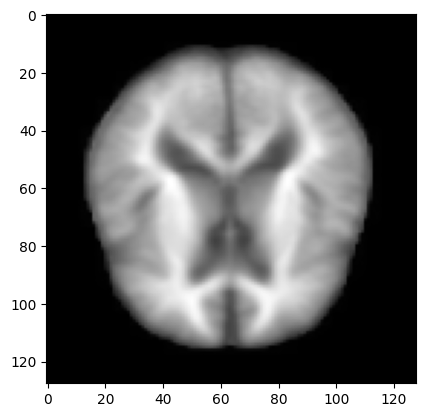

In [7]:
# this is what mean of all real images looks like
plt.imshow(real_images_mean,cmap='gray')

In [17]:
# mean of all images generated by the best generator
best_gen_images_mean = np.mean(best_gen_images,axis=0)
best_gen_images_mean.shape

(128, 128, 1)

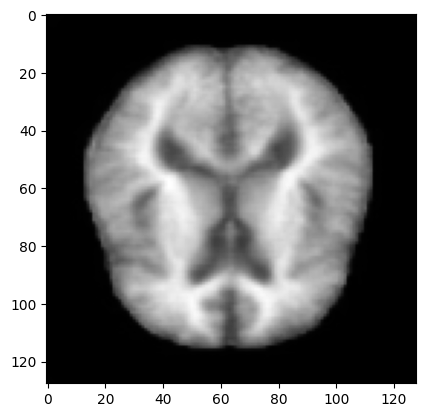

In [9]:
# this is what that mean looks like
plt.imshow(best_gen_images_mean,cmap='gray')

In [10]:
def sharpness_difference(image1, image2):
    from dom import DOM
    bgr_image1 = cv2.cvtColor(image1, cv2.COLOR_GRAY2BGR)
    shp_img1 = DOM().get_sharpness(bgr_image1)
    bgr_image2 = cv2.cvtColor(image2, cv2.COLOR_GRAY2BGR)
    shp_img2 = DOM().get_sharpness(bgr_image2)
    return np.round(abs(shp_img1 - shp_img2),2)

In [12]:
# structural similarity between mean of real images and mean of images generated by the best generator
print('SSIM = {}'.format(np.round(ssim(real_images_mean, best_gen_images_mean,channel_axis=2),2)))

SSIM = 0.96


In [19]:
# peak signal to noise ratio between mean of real images and mean of images generated by the last generator
real_images_mean = real_images_mean * 255.0
best_gen_images_mean = best_gen_images_mean * 255.0
psnr = cv2.PSNR(real_images_mean, best_gen_images_mean)
print('PSNR = {}'.format(np.round(psnr,2)))

PSNR = 29.93


In [14]:
SD = sharpness_difference(real_images_mean, best_gen_images_mean)
print('Sharpness Difference = {}'.format(SD))

Sharpness Difference = 0.07


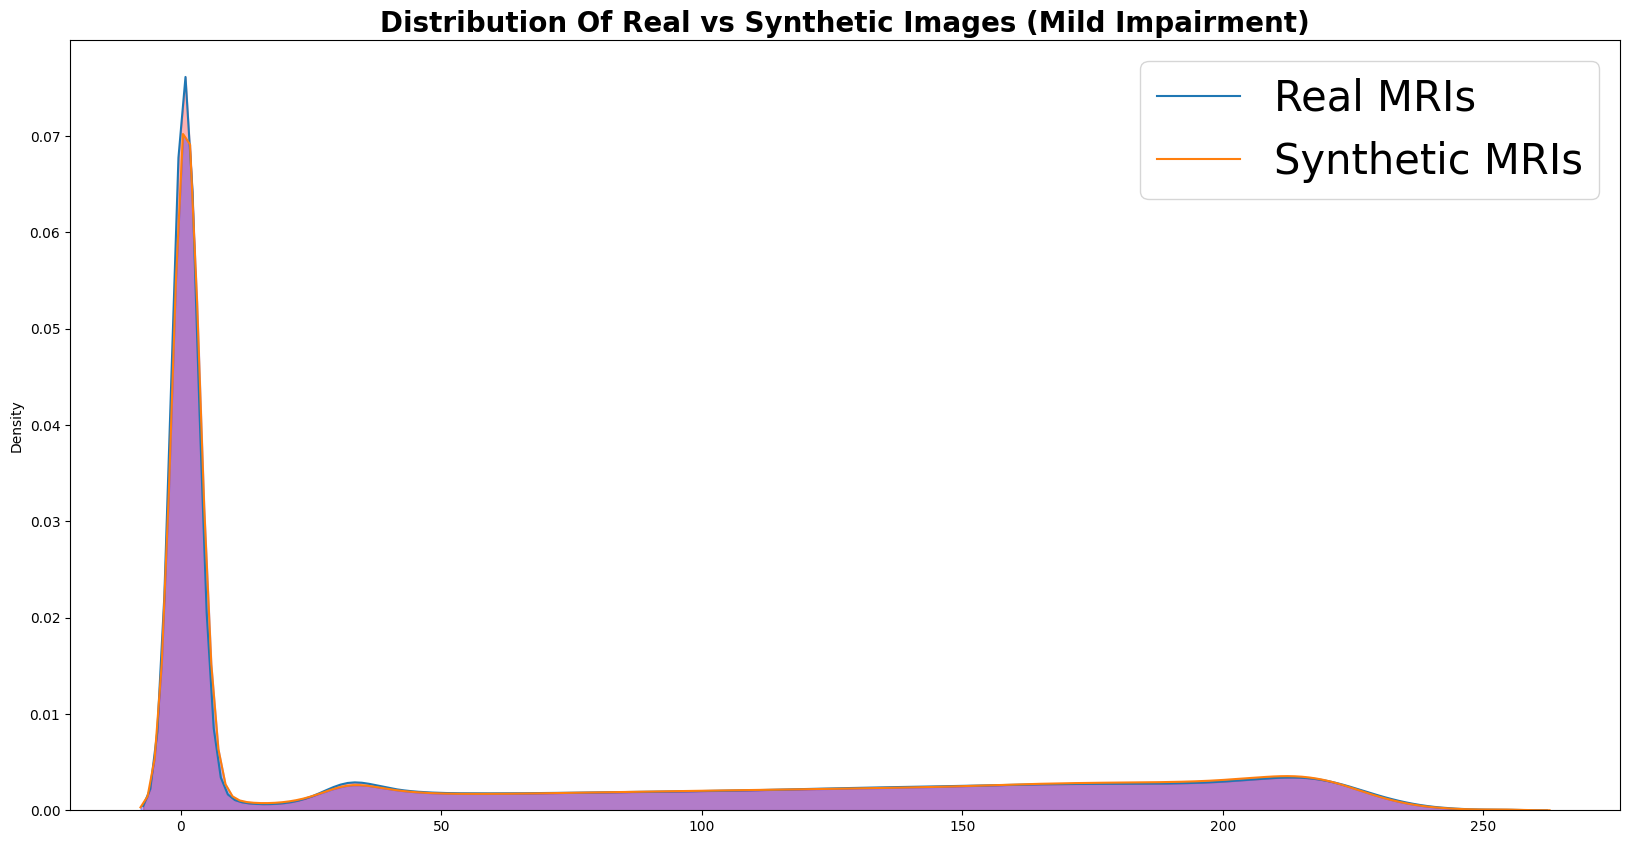

In [13]:
import warnings
warnings.filterwarnings("ignore")

# rescaling images back to 0 to 255
real_images = real_images * 255.0
best_gen_images = best_gen_images * 255.0

fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(20,10))
axs = sns.distplot(real_images, label='Real MRIs', fit_kws={"color":"red"}, hist = None)
axs = sns.distplot(best_gen_images, label='Synthetic MRIs', fit_kws={"color":"blue"}, hist = None)
# Get the two lines from the axes to generate shading
l1 = axs.lines[0]
l2 = axs.lines[1]
# Get the xy data from the lines so that we can shade
x1 = l1.get_xydata()[:,0]
y1 = l1.get_xydata()[:,1]
x2 = l2.get_xydata()[:,0]
y2 = l2.get_xydata()[:,1]
axs.fill_between(x1,y1, color="red", alpha=0.3)
axs.fill_between(x2,y2, color="blue", alpha=0.3)
plt.title('Distribution Of Real vs Synthetic Images (Mild Impairment)', fontsize = 20, fontweight = 'bold')
axs.legend(loc='upper right', prop={'size': 30})
plt.show()

### **MODERATE IMPAIRMENT**

In [14]:
best_gen_img_path = './synthetic_moderate_impairment/'
real_img_path = './Moderate Impairment/'

def img_to_array(folder_path = None):
    images = [cv2.imread(folder_path + image_name, cv2.COLOR_BGR2GRAY) for image_name in os.listdir(folder_path)]
    resized_images = np.array([cv2.resize(i, (IMG_SHAPE[0],IMG_SHAPE[1])) for i in images]).astype(np.float32)
    reshaped_images = resized_images.reshape(resized_images.shape[0], *IMG_SHAPE)/255.0
    return reshaped_images

real_images = img_to_array(folder_path = real_img_path)
best_gen_images = img_to_array(folder_path = best_gen_img_path)

In [5]:
# for best generator's images
calculate_fid(real_images, best_gen_images)

79/79 [==============================] - 300s 4s/step


0.17

In [23]:
# mean of all real images for this class
real_images_mean = np.mean(real_images,axis=0)
real_images_mean.shape

(128, 128, 1)

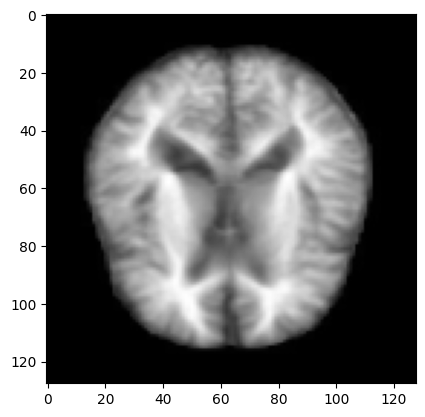

In [10]:
# this is what mean of all real images looks like
plt.imshow(real_images_mean,cmap='gray')

In [24]:
# mean of all images generated by the best generator
best_gen_images_mean = np.mean(best_gen_images,axis=0)
best_gen_images_mean.shape

(128, 128, 1)

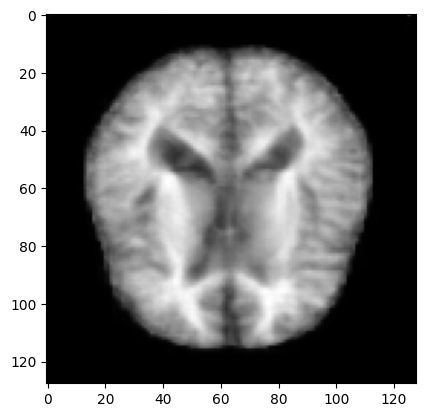

In [12]:
# this is what that mean looks like
plt.imshow(best_gen_images_mean,cmap='gray')

In [ ]:
def sharpness_difference(image1, image2):
    from dom import DOM
    bgr_image1 = cv2.cvtColor(image1, cv2.COLOR_GRAY2BGR)
    shp_img1 = DOM().get_sharpness(bgr_image1)
    bgr_image2 = cv2.cvtColor(image2, cv2.COLOR_GRAY2BGR)
    shp_img2 = DOM().get_sharpness(bgr_image2)
    return np.round(abs(shp_img1 - shp_img2),2)

In [1]:
# structural similarity between mean of real images and mean of images generated by the best generator
print('SSIM = {}%'.format(np.round(ssim(real_images_mean, best_gen_images_mean,channel_axis=2),2)))

SSIM = 0.98


In [ ]:
# peak signal to noise ratio between mean of real images and mean of images generated by the best generator
real_images_mean = real_images_mean * 255.0
best_gen_images_mean = best_gen_images_mean * 255.0
psnr = cv2.PSNR(real_images_mean, best_gen_images_mean)
print('PSNR = {}'.format(np.round(psnr,2)))

PSNR = 32.59


In [21]:
SD = sharpness_difference(real_images_mean, best_gen_images_mean)
print('Sharpness Difference = {}'.format(SD))

Sharpness Difference = 0.0


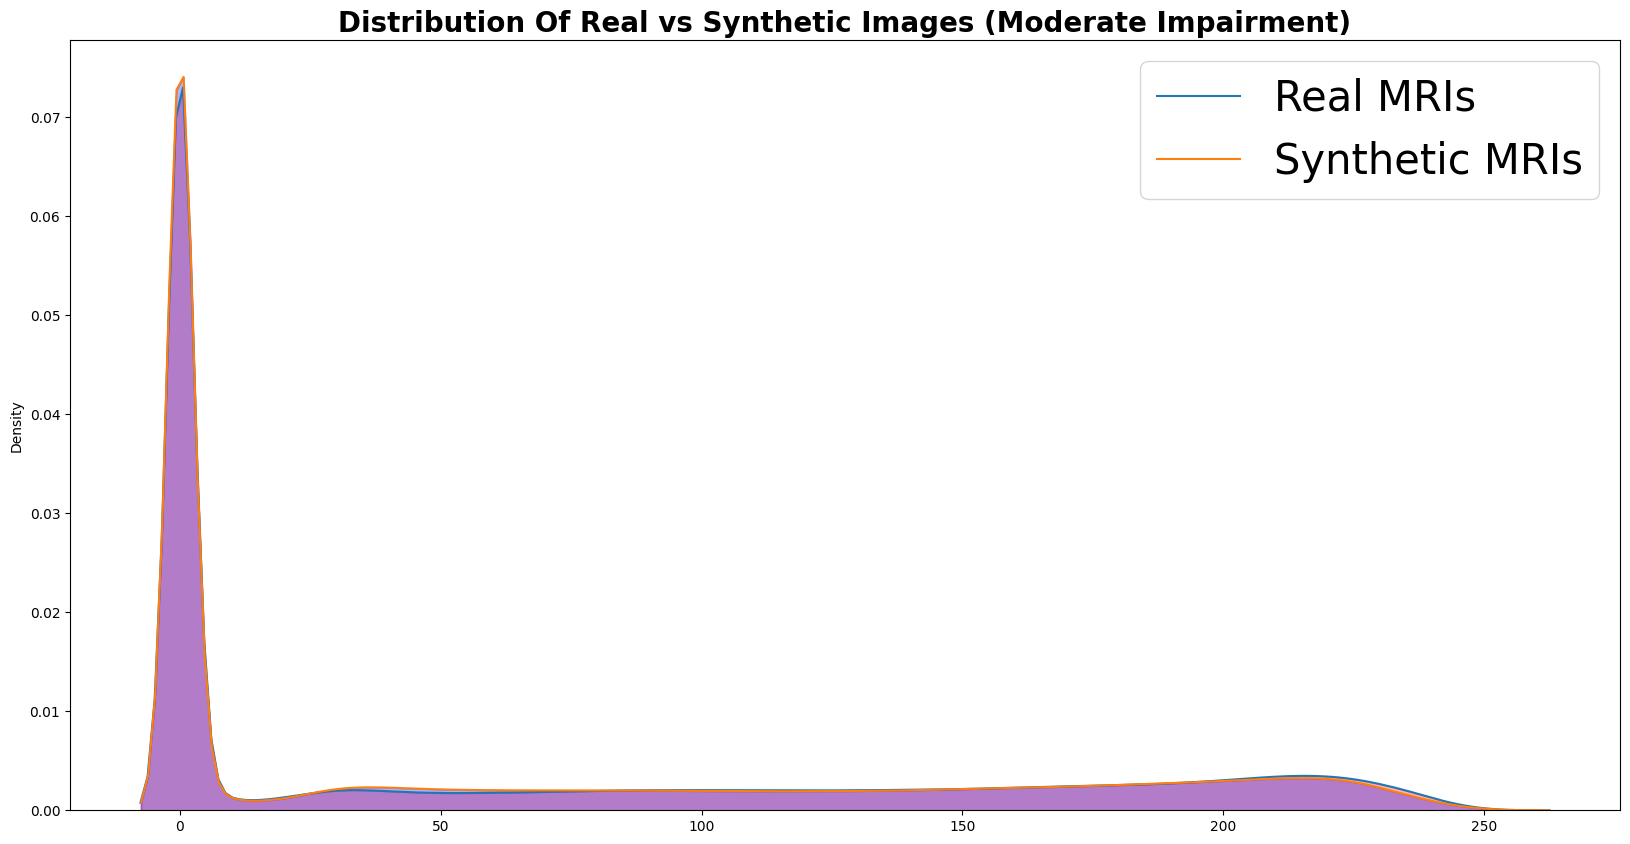

In [15]:
import warnings
warnings.filterwarnings("ignore")

# rescaling images back to 0 to 255
real_images = real_images * 255.0
best_gen_images = best_gen_images * 255.0

fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(20,10))
axs = sns.distplot(real_images, label='Real MRIs', fit_kws={"color":"red"}, hist = None)
axs = sns.distplot(best_gen_images, label='Synthetic MRIs', fit_kws={"color":"blue"}, hist = None)
# Get the two lines from the axes to generate shading
l1 = axs.lines[0]
l2 = axs.lines[1]
# Get the xy data from the lines so that we can shade
x1 = l1.get_xydata()[:,0]
y1 = l1.get_xydata()[:,1]
x2 = l2.get_xydata()[:,0]
y2 = l2.get_xydata()[:,1]
axs.fill_between(x1,y1, color="red", alpha=0.3)
axs.fill_between(x2,y2, color="blue", alpha=0.3)
plt.title('Distribution Of Real vs Synthetic Images (Moderate Impairment)', fontsize = 20, fontweight = 'bold')
axs.legend(loc='upper right', prop={'size': 30})
plt.show()